In [4]:
import torch
from torchvision import transforms
from medmnist import BloodMNIST
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.8 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')


Mounted at /content/drive
Drive mounted.


In [6]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [7]:
train_data = BloodMNIST(split='train', transform=data_transform, download=True)
val_data   = BloodMNIST(split='val', transform=data_transform, download=True)
test_data  = BloodMNIST(split='test', transform=data_transform, download=True)

100%|██████████| 35.5M/35.5M [00:53<00:00, 657kB/s]


In [8]:
print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))

Train size: 11959
Validation size: 1712
Test size: 3421


In [9]:
labels = [int(label) if isinstance(label, (int, float)) else int(label[0]) for _, label in train_data]


class_counts = Counter(labels)


for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples")

Class 7: 1643 samples
Class 3: 2026 samples
Class 6: 2330 samples
Class 2: 1085 samples
Class 1: 2181 samples
Class 5: 993 samples
Class 0: 852 samples
Class 4: 849 samples


In [10]:
total = sum(class_counts.values())
weights = [total / class_counts[i] for i in range(len(class_counts))]
class_weights = torch.tensor(weights, dtype=torch.float)


criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)

Class weights: tensor([14.0364,  5.4833, 11.0221,  5.9028, 14.0860, 12.0433,  5.1326,  7.2788])


In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

In [12]:
!pip install -q timm


In [13]:
import time, copy, os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from torchvision.models import (

    vit_b_16,        ViT_B_16_Weights
)
import matplotlib.pyplot as plt
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 8
BATCH_SIZE  = 64
EPOCHS      = 10          # reduced from 15 — early stopping handles the rest
LR          = 3e-4
PATIENCE    = 3           # stop if val loss doesn't improve for 3 epochs

# Checkpoint directory — saved to Google Drive so Colab disconnects don't lose progress
CHECKPOINT_DIR = '/content/drive/MyDrive/bloodmnist_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CLASS_NAMES = ['basophil','eosinophil','erythroblast','ig','lymphocyte',
               'monocyte','neutrophil','platelet']

print('Device:', DEVICE)
print('Checkpoint dir:', CHECKPOINT_DIR)

Device: cuda
Checkpoint dir: /content/drive/MyDrive/bloodmnist_checkpoints


In [14]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Batches  →  train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}')


Batches  →  train: 187  val: 27  test: 54


In [15]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
print('Class weights:', class_weights.numpy().round(2))


Class weights: [14.04  5.48 11.02  5.9  14.09 12.04  5.13  7.28]


In [16]:
# ── ViT-B/16 ────────────────────────────────────────────────────────────────
def build_vit(num_classes=NUM_CLASSES):
    """ViT-B/16: replace final classification head."""
    m = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
    in_features = m.heads.head.in_features
    m.heads.head = nn.Linear(in_features, num_classes)
    return m


# ── MLP ─────────────────────────────────────────────────────────────────────
def build_mlp(num_classes=NUM_CLASSES, hidden=512):
    """
    Simple MLP baseline.
    Input: 3 × 224 × 224 flattened → two hidden layers → num_classes.
    Uses BatchNorm + Dropout for regularisation.
    """
    in_features = 3 * 224 * 224
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features, hidden),
        nn.BatchNorm1d(hidden),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(hidden, hidden),
        nn.BatchNorm1d(hidden),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(hidden, num_classes),
    )


# Quick sanity-check — forward pass with a dummy batch
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224)
    assert build_vit()(dummy).shape == (2, NUM_CLASSES), 'ViT shape mismatch'
    assert build_mlp()(dummy).shape == (2, NUM_CLASSES), 'MLP shape mismatch'

print('Model builders ready ✓')

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 179MB/s]


Model builders ready ✓


In [17]:
# ================== FIXED run_epoch ==================
def run_epoch(model, loader, optimizer, criterion, training):
    model.train() if training else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []

    with torch.enable_grad() if training else torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.squeeze().long().to(DEVICE)

            logits = model(imgs)
            loss = criterion(logits, labels)

            if training and optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds_all.extend(logits.argmax(1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())

    n = len(loader.dataset)
    avg_loss = total_loss / n
    acc = sum(p == l for p, l in zip(preds_all, labels_all)) / n
    bal_acc = balanced_accuracy_score(labels_all, preds_all)

    return avg_loss, acc, bal_acc, preds_all, labels_all

# ================== Training ==================
def fine_tune(name, model):
    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {k: [] for k in ['tr_loss','tr_acc','val_loss','val_acc','val_bal_acc']}

    best_val_loss = float('inf')  # FIX: track best val_loss for early stopping, not acc
    no_improve = 0

    print(f"\n=== Training {name} ===")

    for epoch in range(1, EPOCHS+1):
        t0 = time.time()

        tr_loss, tr_acc, _, _, _ = run_epoch(model, train_loader, optimizer, criterion, True)

        # FIX: pass None instead of optimizer during validation
        vl_loss, vl_acc, vl_bal_acc, _, _ = run_epoch(model, val_loader, None, criterion, False)

        scheduler.step()

        history['tr_loss'].append(tr_loss)
        history['tr_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_bal_acc'].append(vl_bal_acc)

        # FIX: use val_loss for early stopping (more stable than acc)
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            no_improve = 0
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f'{name}_best.pth'))
        else:
            no_improve += 1

        print(f"Epoch {epoch} | Train Acc {tr_acc:.3f} | Val Acc {vl_acc:.3f} | Val Loss {vl_loss:.4f} | {time.time()-t0:.1f}s")

        if no_improve >= PATIENCE:
            print("Early stopping")
            break

    return model, history

In [18]:
# Mount Google Drive — checkpoints survive Colab disconnections
from google.colab import drive
drive.mount('/content/drive')
vit_model, vit_hist = fine_tune('ViT-B-16', build_vit())
mlp_model, mlp_hist = fine_tune('MLP',      build_mlp())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== Training ViT-B-16 ===
Epoch 1 | Train Acc 0.601 | Val Acc 0.800 | Val Loss 0.5555 | 422.4s
Epoch 2 | Train Acc 0.836 | Val Acc 0.893 | Val Loss 0.3278 | 421.5s
Epoch 3 | Train Acc 0.878 | Val Acc 0.864 | Val Loss 0.3495 | 420.3s
Epoch 4 | Train Acc 0.907 | Val Acc 0.939 | Val Loss 0.2174 | 421.4s
Epoch 5 | Train Acc 0.925 | Val Acc 0.942 | Val Loss 0.1498 | 421.3s
Epoch 6 | Train Acc 0.931 | Val Acc 0.938 | Val Loss 0.1821 | 420.5s
Epoch 7 | Train Acc 0.950 | Val Acc 0.952 | Val Loss 0.1428 | 427.6s
Epoch 8 | Train Acc 0.962 | Val Acc 0.959 | Val Loss 0.1341 | 422.5s
Epoch 9 | Train Acc 0.972 | Val Acc 0.963 | Val Loss 0.1147 | 421.6s
Epoch 10 | Train Acc 0.980 | Val Acc 0.967 | Val Loss 0.1155 | 420.6s

=== Training MLP ===
Epoch 1 | Train Acc 0.670 | Val Acc 0.751 | Val Loss 0.6788 | 28.9s
Epoch 2 | Train Acc 0.783 | Val Acc 0.797 | Val Loss 0.5224 | 2

In [19]:
print(f'\n{"Model":<20} {"Accuracy":>10} ')
print('-' * 47)

test_results = {}

for name, model in [
    ('ViT-B/16', vit_model),
    ('MLP',      mlp_model),
]:
    _, acc, bal, preds, labels = run_epoch(
        model, test_loader, None, criterion, training=False
    )

    test_results[name] = dict(acc=acc, bal_acc=bal, preds=preds, labels=labels)

    print(f'{name:<20} {acc:>10.4f} {bal:>15.4f}')


Model                  Accuracy 
-----------------------------------------------
ViT-B/16                 0.9602          0.9576
MLP                      0.8711          0.8649


In [20]:
for name, res in test_results.items():
    print(f'\n── {name} ──')
    print(classification_report(res['labels'], res['preds'], target_names=CLASS_NAMES))


── ViT-B/16 ──
              precision    recall  f1-score   support

    basophil       0.93      0.93      0.93       244
  eosinophil       1.00      1.00      1.00       624
erythroblast       0.97      0.98      0.98       311
          ig       0.91      0.90      0.90       579
  lymphocyte       0.95      0.95      0.95       243
    monocyte       0.90      0.93      0.92       284
  neutrophil       0.98      0.97      0.97       666
    platelet       1.00      1.00      1.00       470

    accuracy                           0.96      3421
   macro avg       0.95      0.96      0.96      3421
weighted avg       0.96      0.96      0.96      3421


── MLP ──
              precision    recall  f1-score   support

    basophil       0.70      0.76      0.73       244
  eosinophil       0.96      0.96      0.96       624
erythroblast       0.86      0.89      0.88       311
          ig       0.79      0.66      0.72       579
  lymphocyte       0.79      0.90      0.84       2

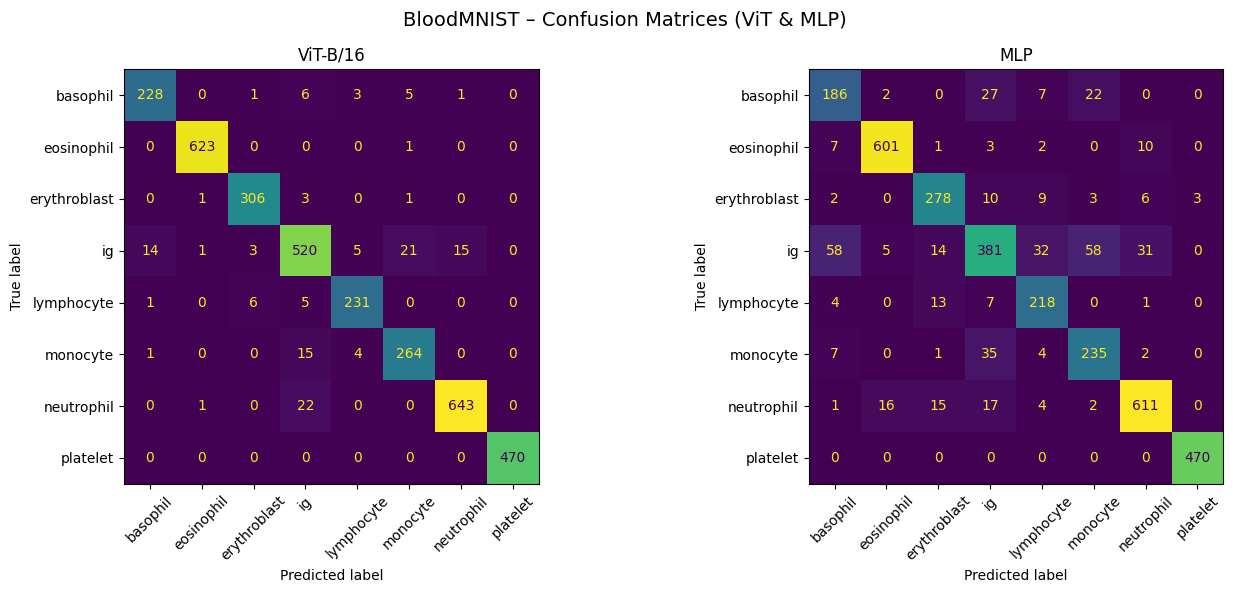

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(res['labels'], res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, xticks_rotation=45
    )
    ax.set_title(name)
plt.suptitle('BloodMNIST – Confusion Matrices (ViT & MLP)', fontsize=14)
plt.tight_layout()
plt.show()

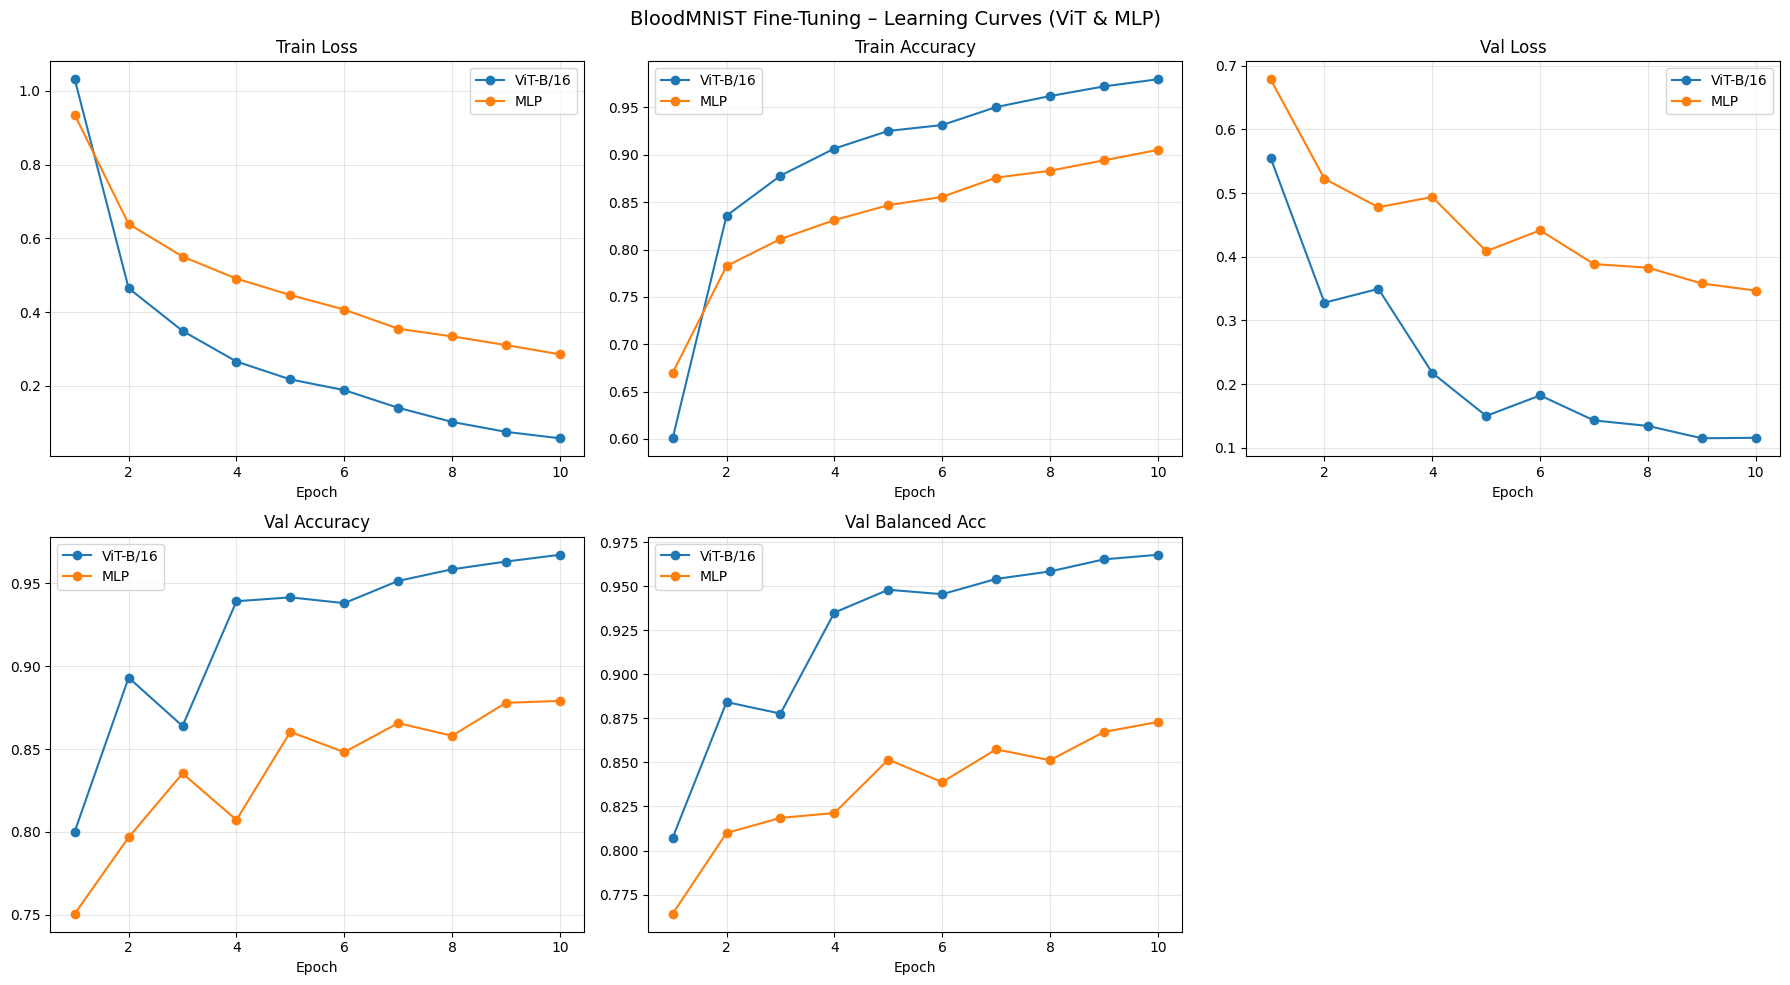

In [22]:
histories = {'ViT-B/16': vit_hist, 'MLP': mlp_hist}
metrics   = [
    ('tr_loss',    'Train Loss'),
    ('tr_acc',     'Train Accuracy'),
    ('val_loss',   'Val Loss'),
    ('val_acc',    'Val Accuracy'),
    ('val_bal_acc','Val Balanced Acc'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (key, title) in zip(axes.flat, metrics):
    for mname, hist in histories.items():
        ax.plot(range(1, len(hist[key]) + 1), hist[key], marker='o', label=mname)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

axes.flat[-1].set_visible(False)   # hide unused 6th subplot
plt.suptitle('BloodMNIST Fine-Tuning – Learning Curves (ViT & MLP)', fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
from google.colab import files
import shutil

for fname in ['vitb_16_best.pth', 'mlp_best.pth']:
    src = os.path.join(CHECKPOINT_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, fname)
        files.download(fname)
        print(f'Downloaded: {fname}')
    else:
        print(f'Not found (training may not have completed): {fname}')

Not found (training may not have completed): vitb_16_best.pth
Not found (training may not have completed): mlp_best.pth


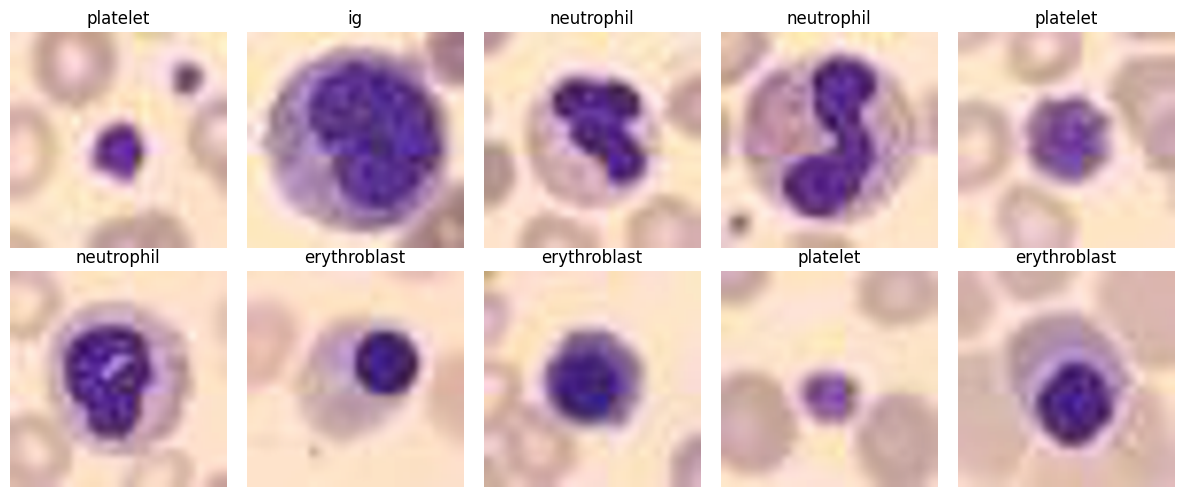

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Mean & std (same as your transform)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Class names
CLASS_NAMES = ['basophil','eosinophil','erythroblast','ig','lymphocyte',
               'monocyte','neutrophil','platelet']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img, label = train_data[i]

    # FIX 1: label shape (important)
    if isinstance(label, (list, tuple, np.ndarray)):
        label = label[0]

    # FIX 2: convert image
    img = img.cpu().numpy().transpose(1, 2, 0)

    # FIX 3: denormalize
    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(CLASS_NAMES[int(label)])
    ax.axis("off")

plt.tight_layout()
plt.show()

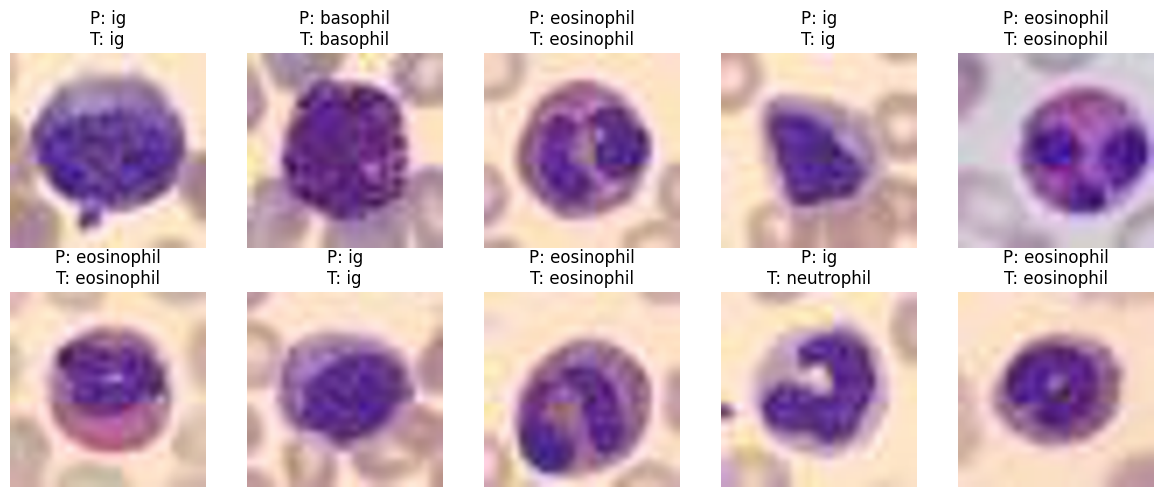

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Mean & std (same as before)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Get a batch from test loader
images, labels = next(iter(test_loader))
images = images.to(DEVICE)

# Get predictions
model = vit_model  # or mlp_model
model.eval()

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

# Plot
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu().numpy().transpose(1, 2, 0)

    # Denormalize
    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    true_label = int(labels[i]) if isinstance(labels[i], (int,float)) else int(labels[i][0])
    pred_label = int(preds[i])

    ax.imshow(img)
    ax.set_title(f"P: {CLASS_NAMES[pred_label]}\nT: {CLASS_NAMES[true_label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

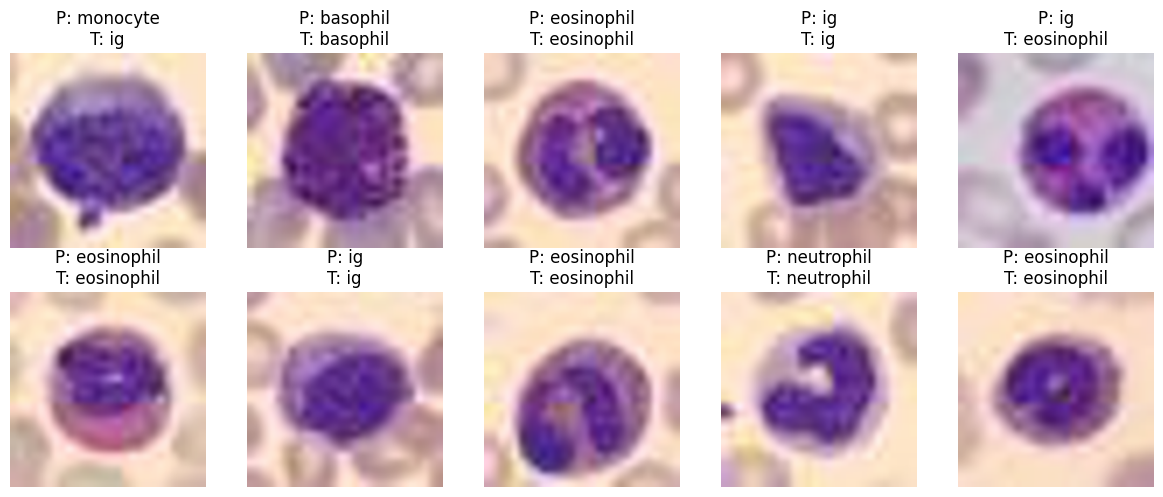

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Mean & std (same as before)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Get a batch from test loader
images, labels = next(iter(test_loader))
images = images.to(DEVICE)

# Get predictions
model = mlp_model
model.eval()

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

# Plot
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu().numpy().transpose(1, 2, 0)

    # Denormalize
    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    true_label = int(labels[i]) if isinstance(labels[i], (int,float)) else int(labels[i][0])
    pred_label = int(preds[i])

    ax.imshow(img)
    ax.set_title(f"P: {CLASS_NAMES[pred_label]}\nT: {CLASS_NAMES[true_label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()